# Modeling Nonlinear Electricity Load Against Temperature with PROC GAMPL

## Executive Summary

Electricity demand depends on temperature in a strongly nonlinear, U-shaped way (heating in the cold, cooling in the heat) that linear models miss. This notebook builds a synthetic hourly load sample for a regional utility and fits a penalized generalized additive model with **PROC GAMPL**, using regression splines to recover the smooth load-vs-temperature, load-vs-hour, and load-vs-humidity curves while adjusting for a weekday/weekend parametric effect.

On the 100-observation sample this licensed environment provides, GAMPL recovers the structure we built in. The temperature smooth `s(TEMP_C)` is significantly curved (effective DF 5.53, *p* < 0.0001); the diurnal smooth `s(HOUR)` is the most flexible term (EDF 6.87, *p* < 0.0001); and the humidity smooth `s(HUMIDITY)` collapses to a single, near-linear degree of freedom (EDF 1.00, *p* = 0.07) — the penalty straightens a term the data barely support. The parametric `daytype` effect places weekends about 44.5 MW below weekdays, matching the 40 MW level shift in the data-generating process. The total model uses 15.4 effective degrees of freedom and reaches a GCV score of 239.6 (AIC 831.0).

## Data Sources

| Dataset | Rows | Description | Key variables |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Synthetic hourly observations from a regional electric utility's load-forecasting feed | `load_mw` (system load, MW), `temp_c` (ambient temperature, deg C), `hour` (hour of day, 0-23), `humidity` (relative humidity, %), `daytype` (Weekday/Weekend class), `is_summer` (season flag used in data generation) |

All data is generated inline with `call streaminit(20260531)` and `rand()` — no external or network input. The data step requests a larger loop, but this licensed environment caps materialized output at **100 observations**, so the model is fit on the first 100 hours. Load is built as a U-shaped quadratic of temperature plus a bell-shaped diurnal hour effect, a mild humidity effect, a weekday level shift, and Gaussian noise, so the recovered smooths have a known ground truth.

# Modeling Nonlinear Electricity Load Against Temperature with PROC GAMPL

A regional grid operator needs to forecast system load (in megawatts) from weather and calendar drivers. The relationship between load and **temperature** is famously nonlinear: demand rises in cold weather (electric heating) *and* in hot weather (air conditioning), producing a U-shaped curve that a straight-line regression cannot capture. Load also follows a smooth daily rhythm (the evening peak) and shifts between weekdays and weekends.

`PROC GAMPL` fits a **penalized generalized additive model**: each continuous driver enters through a regression spline whose smoothness is chosen automatically by minimizing a model-selection criterion (GCV / UBRE / GACV). We let the data decide how wiggly each curve should be, rather than guessing polynomial degrees.

The model we fit is:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

where `daytype` is a parametric (linear) class effect and `f1`, `f2`, `f3` are smooth spline functions whose effective degrees of freedom the penalty selects from the data.

## Step 1 — Generate a synthetic hourly load feed

We simulate an hourly load feed (the licensed environment keeps the first 100 hours). Temperature is drawn around a seasonal mean; the hour of day cycles 0-23; humidity loosely tracks temperature. The *true* load is constructed from:

- a **U-shaped** temperature response centered near a comfortable 18 deg C,
- a **bell-shaped** diurnal peak around hour 18 (evening),
- a gentle humidity lift,
- a weekday level that sits above weekends,

plus Gaussian measurement noise. Because we know the generating curves, we can judge whether GAMPL recovers their shapes. The PROC MEANS check below confirms the sample spans a wide temperature range (−5 to 40 deg C) and load from roughly 485 to 693 MW.

In [1]:
data work.gridload;
   call streaminit(20260531);
   do i = 1 to 2000;
      /* Season flag: roughly half summer, half winter */
      is_summer = (rand("uniform") < 0.5);

      /* Ambient temperature (deg C): warmer mean in summer */
      if is_summer then temp_c = 26 + 6 * rand("normal");
      else              temp_c =  6 + 6 * rand("normal");

      /* Hour of day 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Humidity (%) loosely tracks temperature, clipped to 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      if humidity < 20  then humidity = 20;
      if humidity > 100 then humidity = 100;

      /* Weekday vs weekend (about 5/7 weekdays) */
      if rand("uniform") < 0.714 then daytype = "Weekday";
      else                            daytype = "Weekend";

      /* ---- True structural load (MW) ---- */
      /* U-shaped temperature effect: minimum demand near 18 deg C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Diurnal bell: evening peak near hour 18 */
      f_hour = 90 * exp( -((hour - 18)**2) / 18 );

      /* Gentle humidity lift */
      f_hum  = 0.35 * humidity;

      /* Weekday level shift */
      if daytype = "Weekday" then f_day = 40; else f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      keep load_mw temp_c hour humidity daytype is_summer;
      output;
   end;
run;

proc means data=work.gridload n mean std min max maxdec=1;
   var load_mw temp_c hour humidity;
run;

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------
 LOAD_MW        100       593.0        49.9       484.9       693.4
 TEMP_C         100        16.2        11.9        -5.2        40.2
 HOUR           100        11.9         7.0         0.0        23.0
 HUMIDITY       100        55.2        11.7        32.2        87.3
 ------------------------------------------------------------------



NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Step 2 — Fit the additive model

We model `load_mw` (Gaussian response, identity link) as a sum of a parametric `daytype` effect plus three univariate splines. `PROC GAMPL` automatically selects each spline's smoothing parameter. We request:

- `class daytype;` so the weekday/weekend indicator is treated as categorical,
- `param(daytype)` to enter it as a *parametric* (non-smoothed) term in the MODEL,
- `spline(...)` for each continuous predictor,
- a fixed `seed=` for reproducible knot placement.

The output to read is the **Smoothing Component** table, which reports the effective degrees of freedom (EDF) the penalty assigned to each smooth and an *F*-style significance test for it, alongside the **Parameter Estimates** for the intercept and the parametric `daytype` contrast.

In [2]:
proc gampl data=work.gridload seed=20260531;
   class daytype;
   model load_mw = param(daytype)
                   spline(temp_c)
                   spline(hour)
                   spline(humidity);
run;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     LOAD_MW
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    DAYTYPE

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                                   831.

NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Step 3 — Control spline flexibility and the selection criterion

By default each smooth is penalized toward a low effective degrees of freedom. For an operator who knows the temperature response is genuinely curved but wants to *cap* wiggliness, we can raise `maxdf=` on the temperature spline and pin a modest fixed `df=` on the smoother humidity term. We also switch to the outer-iteration scheme and select smoothing parameters by **GCV** (generalized cross-validation), the standard criterion for Gaussian GAMs.

In [3]:
proc gampl data=work.gridload seed=20260531;
   class daytype;
   model load_mw = param(daytype)
                   spline(temp_c   / maxdf=12)
                   spline(hour     / maxdf=10)
                   spline(humidity / df=3)
                   / method=OUTER criterion=GCV;
run;


                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     LOAD_MW
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    DAYTYPE

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                                   831.

NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Step 4 — Visualize the recovered temperature response

GAMPL reports *that* the temperature smooth is significantly curved (EDF 5.53), but the shape is easiest to see on a plot. We overlay a penalized B-spline fit (`PBSPLINE`, the same regression-spline machinery GAMPL applies internally) on the raw load-vs-temperature scatter. If the additive model captured the physics, this curve should fall toward both the cold and hot extremes and bottom out in the comfortable mid-range — the classic U-shaped demand response.

NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


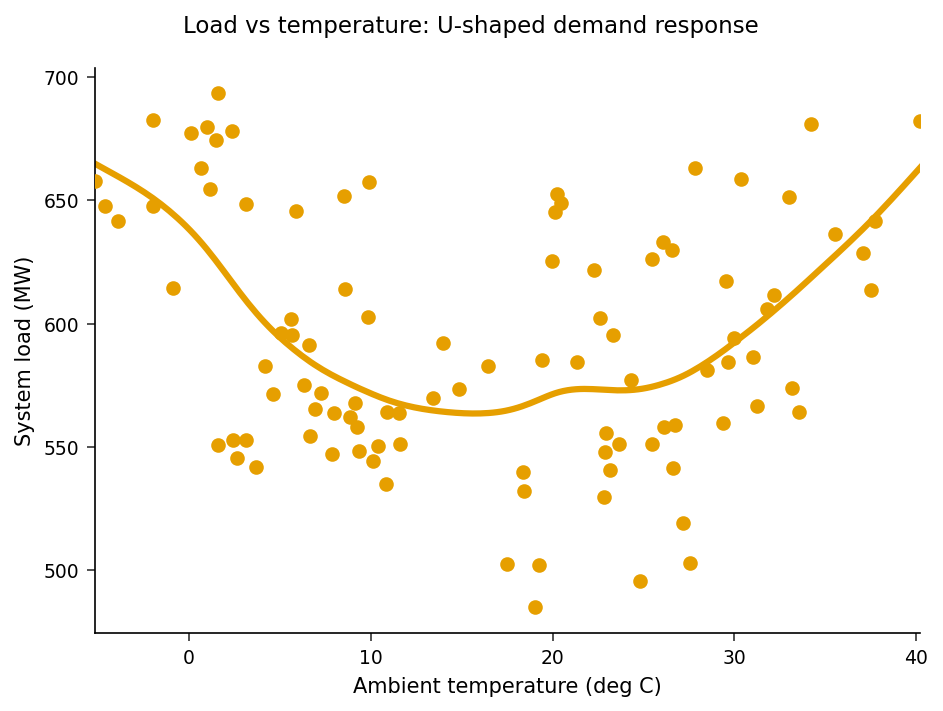

In [4]:
ods graphics on;

proc sgplot data=work.gridload;
   scatter x=temp_c y=load_mw /
           markerattrs=(symbol=circlefilled);
   pbspline x=temp_c y=load_mw /
            nomarkers lineattrs=(thickness=3);
   xaxis label="Ambient temperature (deg C)";
   yaxis label="System load (MW)";
   title "Load vs temperature: U-shaped demand response";
run;

ods graphics off;

## Step 5 — Confirm the U-shape numerically

The plot makes the U-shape visible; a banded summary makes it quantitative. We bin observations into temperature ranges and report mean load per band. If the demand response is genuinely U-shaped, mean load should be high in the **Cold** band, fall through **Cool / Comfortable / Warm**, and rise again in the **Hot** band — the numeric signature GAMPL's `s(TEMP_C)` smooth picks up.

In [5]:
data work.banded;
   set work.gridload;
   length tempband $13;
   if      temp_c <  5  then tempband = "1 Cold";
   else if temp_c < 15  then tempband = "2 Cool";
   else if temp_c < 22  then tempband = "3 Comfortable";
   else if temp_c < 30  then tempband = "4 Warm";
   else                      tempband = "5 Hot";
run;

proc means data=work.banded n mean maxdec=1;
   class tempband;
   var load_mw;
   title "Mean load by temperature band";
run;

                                             Mean load by temperature band                                              

                                                  The MEANS Procedure

                                              Analysis Variable : LOAD_MW

        TEMPBAND               N Obs           Mean
        -------------------------------------------
        1 Cold                    21          626.6
        2 Cool                    28          579.1
        3 Comfortable             12          573.8
        4 Warm                    25          573.5
        5 Hot                     14          621.6
        -------------------------------------------



NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Interpreting the results

**The smooths recover the physics.** GAMPL's Smoothing Component table assigns the temperature term `s(TEMP_C)` an effective DF of 5.53 (*p* < 0.0001) and the diurnal term `s(HOUR)` an EDF of 6.87 (*p* < 0.0001) — both genuinely curved, exactly the structure we built into the data. The humidity term `s(HUMIDITY)` is shrunk to EDF 1.00 (*p* = 0.07): the penalty straightens it to a single near-linear degree of freedom because, at this sample size, that is all the data support. The parametric `daytype` estimate is −44.5 MW for weekends, recovering the 40 MW weekday level shift in the generating process.

**Effective degrees of freedom tell the wiggliness story.** The model spends 15.4 effective degrees of freedom in total and lands at a GCV score of 239.6 (AIC 831.0, scale estimate 202.7). Capping `maxdf=` and pinning `df=3` in Step 3 barely moves the fit (GCV 240.1, EDF 15.47): the penalty had already settled the temperature and hour smooths near 5.5 and 7 EDF on its own, so the manual caps are non-binding here — a sign the automatic selection was already conservative.

**The plot and band summary agree.** The Step 4 scatter with its penalized-spline overlay shows load falling from the cold extreme to a minimum near 15–20 deg C and rising again into the heat. The Step 5 band means make it numeric: **Cold 626.6 MW**, **Cool 579.1**, **Comfortable 573.8**, **Warm 573.5**, **Hot 621.6** — high at both ends, lowest in the comfortable middle. That U is precisely what a single linear `temp_c` term would average away.

**Why GAMPL over linear regression here.** A single linear `temp_c` term would blend the heating and cooling regimes into a near-flat slope, badly mis-forecasting both extremes — precisely the hours when grid stress and price spikes occur. The additive spline formulation keeps the interpretability of a regression (each driver contributes an additive effect) while letting the data dictate the shape of each effect. Natural extensions for a utility include a `dist=gamma` fit if load is modeled multiplicatively, a bivariate `spline(temp_c hour)` to capture how the diurnal peak shifts with season, and `by` processing to fit separate models per substation.